### Importing libraries, datasets and geospatial data

In [2]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import os
from sklearn.cluster import KMeans
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

In [ ]:
# Load Food-101 dataset (streaming from HuggingFace hub)
dataset = load_dataset("food101")

# extract the restaurants from and city boundaries
city_name = "Reggio Emilia, Italy"
tags = {"amenity": "restaurant"}
restaurants = ox.features_from_place(city_name, tags).reset_index()
city_boundary = ox.geocode_to_gdf(f"{city_name}")

## Geospatial part

In [9]:
# filter the features to keep only name, cuisine and area (geometry coordinates)

gdf = restaurants[["name", "cuisine", "geometry"]].dropna(subset=["name", "cuisine", "geometry"])

def get_lon(g):
    if g.geom_type == "Point":
        return g.x
    else:
        return g.centroid.x

def get_lat(g):
    if g.geom_type == "Point":
        return g.y
    else:
        return g.centroid.y

# save latitude and longitude and remove geometry column
gdf["lon"] = gdf.geometry.apply(get_lon)
gdf["lat"] = gdf.geometry.apply(get_lat)

gdf.drop(columns=["geometry"], inplace=True)

# cuisine characteristics
gdf.cuisine.unique()

array(['regional', 'primi_emiliani;burger;tex-mex;regional', 'italian',
       'ramen', 'italian;pizza', 'italian_pizza;italian',
       'italian;regional;grill;steak_house', 'pizza;italian', 'pizza',
       'sandwich;steak_house', 'organic', 'chinese', 'regional;organic',
       'regional;pizza', 'japanese;chinese', 'pizza;regional',
       'italian;pizza;regional', 'regional;argentinian', 'tradizionale',
       'argentinian', 'pizza;fritti;insalata_di_mare;Bevande',
       'japanese;ramen', 'mexican', 'japanese', 'regional;fish;pizza',
       'chinese;japanese;italian', 'steak_house',
       'chinese;japanese;sushi', 'burger', 'asian;chinese;japanese',
       'italian;tuscan', 'georgian', 'italian;coffee_shop',
       'regional;italian', 'regional;italian;pizza', 'italian;regional',
       'sushi;japanese', 'meat;italian;regional;steak_house',
       'italian;fish;pizza', 'sandwich;italian', 'pizza;italian;fish',
       'crepe;diner;italian;local', 'italian;steak_house;barbecue',
   

In [20]:
# drop columns where cuisine is NaN and split the multi-cuisine in unique words
gdf_expanded = gdf.dropna(subset=["cuisine"]).copy()
gdf_expanded["cuisine"] = gdf_expanded["cuisine"].str.split(";")
gdf_expanded = gdf_expanded.explode("cuisine")
print(f"All cuisine you can find in {city_name}:")
gdf_expanded["cuisine"].unique()

All cuisine you can find in Reggio Emilia, Italy:


array(['regional', 'primi_emiliani', 'burger', 'tex-mex', 'italian',
       'ramen', 'pizza', 'italian_pizza', 'grill', 'steak_house',
       'sandwich', 'organic', 'chinese', 'japanese', 'argentinian',
       'tradizionale', 'fritti', 'insalata_di_mare', 'Bevande', 'mexican',
       'fish', 'sushi', 'asian', 'tuscan', 'georgian', 'coffee_shop',
       'meat', 'crepe', 'diner', 'local', 'barbecue', 'ice_cream', 'poké',
       'brazilian', 'poke', 'international', 'indian', 'hawaiian',
       'seafood', 'kebab', 'breakfast', 'traditional', 'greek',
       'american', 'thai'], dtype=object)

In [21]:
# let's cluster the OSM cuisines in macro categories
 
macro_cuisines = {
    "tradizionale": ["italian","primi_emiliani","tuscan","tradizionale","traditional","regional","local"],
    "pizza": ["pizza","italian_pizza"],
    "chinese": ["chinese", "asian"],
    "japanese": ["japanese","ramen","sushi"],
    "thai": ["thai"],
    "indian": ["indian"],
    "american": ["burger","sandwich","steak_house","barbecue","grill","breakfast","diner", "tex-mex", "american"],
    "latin_american": ["mexican","argentinian","brazilian"],
    "greek": ["greek"],
    "sea-food": ["seafood","fish","insalata_di_mare"],
    "kebab": ["kebab"],
    "hawaiian": ["poké","poke","hawaiian"],
}

cuisine_map = {sub: main for main, sublist in macro_cuisines.items() for sub in sublist}
gdf_expanded["cuisine_main"] = gdf_expanded["cuisine"].map(cuisine_map)
gdf_expanded = gdf_expanded.dropna(subset=["cuisine_main"])
gdf_expanded = gdf_expanded.drop_duplicates(subset=["name", "cuisine_main"])
gdf_expanded = gdf_expanded.reset_index(drop=True)
gdf_expanded.head()

,name,cuisine,lon,lat,cuisine_main
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale
2,Birreria Red Mosquito,burger,10.667718,44.597387,american
3,Il Portone,regional,10.686533,44.598640,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale


In [25]:
# create a new column `cuisine_main_all` for those restaurants that offer more than 1 macro cuisine
cuisine_map = gdf_expanded.groupby('name')['cuisine_main'].unique().to_dict()
gdf_expanded['cuisine_main_all'] = gdf_expanded['name'].map(lambda x: "; ".join(cuisine_map[x]))
gdf_expanded

,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale,tradizionale; american
2,Birreria Red Mosquito,burger,10.667718,44.597387,american,tradizionale; american
3,Il Portone,regional,10.686533,44.598640,tradizionale,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale,tradizionale
...,...,...,...,...,...,...
287,Asian Dumplings JO,thai,10.650784,44.715078,thai,chinese; japanese; thai
288,Màs Mexico,mexican,10.651260,44.714734,latin_american,latin_american
289,"Lago Pranda pizzeria,griglia",regional,10.242901,44.303645,tradizionale,tradizionale; pizza
290,"Lago Pranda pizzeria,griglia",pizza,10.242901,44.303645,pizza,tradizionale; pizza


In [ ]:
# find places that offer multiple macro-cuisine. they will be assigned the black color in the map
multi_cuisine_restaurants = gdf_expanded[gdf_expanded.duplicated(subset=["name"], keep=False)]["name"].unique()

color_dict = {
        "tradizionale": "red",
        "pizza": "orange",
        "chinese": "green",
        "japanese": "blue",
        "thai": "purple",
        "indian": "pink",
        "american": "cadetblue",
        "latin_american": "darkred",
        "greek": "beige",
        "sea-food": "lightblue",
        "kebab": "darkgreen",
        "hawaiian": "lightred"
    }

def get_color(row, color_dict=color_dict):
    if len(cuisine_map[row['name']]) > 1:
        return "black"  # multi-cuisine
    
    return color_dict.get(row['cuisine_main'], "gray")

In [29]:
gdf_expanded.head()

,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
0,Circolo Della Caccia Monte Vangelo,regional,10.688045,44.569479,tradizionale,tradizionale
1,Birreria Red Mosquito,primi_emiliani,10.667718,44.597387,tradizionale,tradizionale; american
2,Birreria Red Mosquito,burger,10.667718,44.597387,american,tradizionale; american
3,Il Portone,regional,10.686533,44.598640,tradizionale,tradizionale
4,Antiche mura,italian,10.687861,44.598367,tradizionale,tradizionale


In [ ]:
# create an interactive map where you can see all the filtered restaurants with their relative cuisine

import folium
import webbrowser
from folium.plugins import MarkerCluster
from branca.element import Template, MacroElement

map_file = "reggio_emilia_map.html"

legend_html = """
{% macro html(this, kwargs) %}
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 170px; height: 320px; 
    border:2px solid grey; z-index:9999; font-size:14px;
    background-color:white;
    padding: 10px;
    ">
    <b>Legend</b><br>
"""
for cuisine, color in color_dict.items():
    legend_html += f"""<i style="background:{color};width:15px;height:15px;display:inline-block;margin-right:5px"></i>{cuisine}<br>"""
legend_html += """<i style="background:black;width:15px;height:15px;display:inline-block;margin-right:5px"></i>multi-cuisine<br>"""

legend_html += "</div>{% endmacro %}"

# Add to folium map
template = Template(legend_html)
macro = MacroElement()
macro._template = template

center = [gdf_expanded.lat.mean(), gdf_expanded.lon.mean()]
m = folium.Map(location=center, zoom_start=12)

folium.GeoJson(
    city_boundary.geometry,
    style_function=lambda x: {
        'color': 'black',
        'weight': 3,
        'fill': False
    }
).add_to(m)

# Add restaurants
for idx, row in gdf_expanded.iterrows():
    popup_text = f"<b>{row['name']}</b><br>Cucina: {row['cuisine_main_all']}"
    folium.Marker(
        location=[row.lat, row.lon],
        popup=popup_text,
        icon=folium.Icon(color=get_color(row))
    ).add_to(m)

m.get_root().add_child(macro)

m.save(map_file)
# Open the HTML file in the default web browser
webbrowser.open(f"file://{os.path.realpath(map_file)}")


True

## Computer vision part

In [ ]:
from collections import Counter
train_data = dataset["train"]
test_data = dataset["validation"]

labels = train_data["label"]  # these are indices

# Map indices to names
label_names = train_data.features["label"].names
label_strings = [label_names[i] for i in labels]

# Count images per dish
counts = Counter(label_strings)

# every food class has 750 items (images)
list(counts.items())[:10]

[('beignets', 750),
 ('prime_rib', 750),
 ('ramen', 750),
 ('hamburger', 750),
 ('bruschetta', 750),
 ('chicken_wings', 750),
 ('pork_chop', 750),
 ('greek_salad', 750),
 ('sashimi', 750),
 ('risotto', 750)]

In [40]:
print(test_data.features["label"].names)
print(f"The len of the dataset classes is: {len(test_data.features['label'].names)}")

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheesecake', 'cheese_plate', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

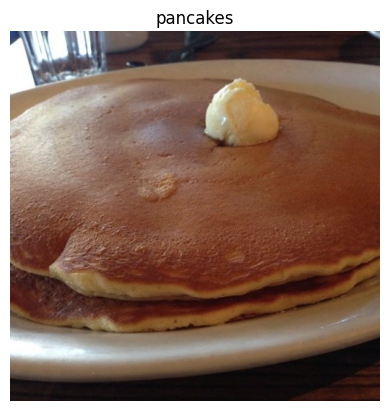

In [ ]:
# plot a random image of a random class
import random
selected_class = random.choice(test_data.features["label"].names)
indices = [i for i, lbl in enumerate(train_data["label"]) if label_names[lbl] == selected_class]

# Pick a random index
rand_idx = random.choice(indices)

# Get image
img = train_data[rand_idx]["image"]

# Plot
plt.imshow(img)
plt.axis("off")
plt.title(selected_class)
plt.show()

In [45]:
# for each macro cuisine we defined previously, we selected one or more food we can find there.
# They obviously need to be between the food dataset classes
 
food_subset = {
    "tradizionale": ["spaghetti_carbonara", "lasagna", "risotto", "ravioli"],
    "pizza": ["pizza"],
    "chinese": ["fried_rice", "dumplings", "peking_duck"],
    "japanese": ["ramen", "sushi", "sashimi", "takoyaki", "edamame"],
    "indian": ["chicken_curry", "samosa"],
    "american": ["hamburger", "pancakes", "chicken_wings", "hot_dog", "pulled_pork_sandwich"],
    "latin_american": ["tacos", "ceviche", "breakfast_burrito", "guacamole", "nachos"],
    "sea-food": ["mussels", "scallops", "shrimp_and_grits", "fried_calamari"],
    "middle_eastern": ["falafel", "hummus"],
}
selected_dishes = [dish for dishes in food_subset.values() for dish in dishes]

def filter_subset(example):
    return label_names[example['label']] in selected_dishes

# filter the dataset keeping only the images with the selected dishes
train_data = dataset['train'].filter(filter_subset)
# removing a specific image in the dataset that is not related to food
indices_to_keep = [i for i in range(len(train_data)) if i != 9504]
train_data = train_data.select(indices_to_keep)

val_data = dataset['validation'].filter(filter_subset)

# split train data to create also test set
splits = train_data.train_test_split(test_size=0.2, seed=42)
train_data = splits["train"]
test_data  = splits["test"]

In [44]:
train_data, val_data, test_data

(Dataset({
     features: ['image', 'label'],
     num_rows: 18599
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 7750
 }),
 Dataset({
     features: ['image', 'label'],
     num_rows: 4650
 }))

In [46]:
# Get unique labels in the filtered train_data
unique_labels = sorted(set(train_data['label']))

# Create a mapping from old indices to new contiguous indices
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
print("Label Mapping:", label_mapping)

# Reindex labels in train_data
def reindex_labels(example):
    example['label'] = label_mapping[example['label']]
    return example

train_data = train_data.map(reindex_labels)
val_data = val_data.map(reindex_labels)
test_data = test_data.map(reindex_labels)


Label Mapping: {9: 0, 15: 1, 18: 2, 20: 3, 32: 4, 33: 5, 36: 6, 43: 7, 44: 8, 51: 9, 53: 10, 55: 11, 57: 12, 59: 13, 65: 14, 66: 15, 72: 16, 74: 17, 76: 18, 80: 19, 81: 20, 82: 21, 84: 22, 85: 23, 86: 24, 87: 25, 89: 26, 91: 27, 95: 28, 96: 29, 97: 30}


Map:   0%|          | 0/18599 [00:00<?, ? examples/s]

Map:   0%|          | 0/7750 [00:00<?, ? examples/s]

Map:   0%|          | 0/4650 [00:00<?, ? examples/s]

In [47]:
num_classes = len(label_mapping)
print(f"Number of classes after reindexing: {num_classes}")

Number of classes after reindexing: 31


In [ ]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Randomly flip images horizontally
    transforms.RandomRotation(10),     # Randomly rotate images by ±10 degrees
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# food class and dataloader necessary for training with pytorch
class FoodDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example['image']
        label = example['label']

        if self.transform:
            image = self.transform(image)

        return image, label
    
BATCH_SIZE = 256  # You can adjust this value as needed
NUM_WORKERS = 16 # need to be adjusted based on laptop capabilities
train_dataset = FoodDataset(train_data, transform=train_transform)
val_dataset = FoodDataset(val_data, transform=transform)
test_dataset = FoodDataset(test_data, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
train_labels = set(train_data['label'])
val_labels = set(val_data['label'])
test_labels = set(test_data['label'])

# we can that all classes are present in every subset
print(len(train_labels))
print(len(val_labels))
print(len(test_labels))

31
31
31


In [ ]:
# take a batch (256 images with corresponding labels)
imgs, labels = next(iter(train_loader))

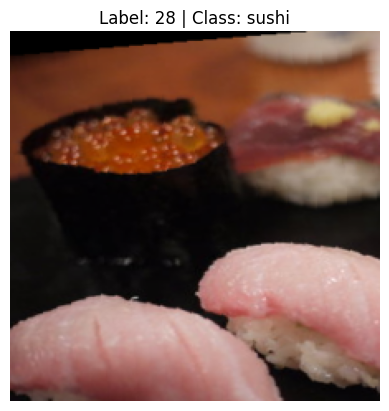

In [58]:
# plot an image extracted from the dataloader

reindexed_to_class = {new_label: label_names[old_label] for old_label, new_label in label_mapping.items()}

idx = random.randint(0, len(imgs) - 1)  # Ensure the index is within the batch size
img = imgs[idx]

# Inverse normalization for display
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
plt.imshow(np.clip(img_disp, 0, 1))
plt.axis("off")
label_int = labels[idx].item()
class_name = reindexed_to_class[label_int]  # Use the correct mapping
plt.title(f"Label: {label_int} | Class: {class_name}")
plt.show()

In [60]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
num_classes = len(set(train_data['label']))
print(num_classes)

cuda
31


In [61]:
# define a basic CNN
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [64]:
# wait for the manual input to carry on with training:
input("Press Enter to continue with model training...")

''

### Model training needs a lot of time. Therefore, I run it for just 20 epochs and it reached around 85% of accuracy in the validation set

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 20
train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []
patience = 5
best_val_loss = float("inf")
patience_counter = 0
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()*imgs.size(0)
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
    
    train_loss = running_loss/total
    train_acc = correct/total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    
    # Validation
    model.eval()
    running_loss, correct, total = 0,0,0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()*imgs.size(0)
            _, preds = torch.max(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)
    
    val_loss = running_loss/total
    val_acc = correct/total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.3f} Acc: {train_acc:.3f} | Val Loss: {val_loss:.3f} Acc: {val_acc:.3f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/20 - Train Loss: 2.123 Acc: 0.448 | Val Loss: 1.159 Acc: 0.692
Epoch 2/20 - Train Loss: 1.245 Acc: 0.668 | Val Loss: 0.834 Acc: 0.768
Epoch 3/20 - Train Loss: 1.028 Acc: 0.723 | Val Loss: 0.732 Acc: 0.791
Epoch 4/20 - Train Loss: 0.917 Acc: 0.750 | Val Loss: 0.682 Acc: 0.808
Epoch 5/20 - Train Loss: 0.812 Acc: 0.776 | Val Loss: 0.650 Acc: 0.812
Epoch 6/20 - Train Loss: 0.756 Acc: 0.791 | Val Loss: 0.609 Acc: 0.823
Epoch 7/20 - Train Loss: 0.694 Acc: 0.808 | Val Loss: 0.607 Acc: 0.820
Epoch 8/20 - Train Loss: 0.650 Acc: 0.820 | Val Loss: 0.592 Acc: 0.827
Epoch 9/20 - Train Loss: 0.608 Acc: 0.830 | Val Loss: 0.592 Acc: 0.830
Epoch 10/20 - Train Loss: 0.567 Acc: 0.841 | Val Loss: 0.589 Acc: 0.826
Epoch 11/20 - Train Loss: 0.535 Acc: 0.850 | Val Loss: 0.623 Acc: 0.817
Epoch 12/20 - Train Loss: 0.504 Acc: 0.858 | Val Loss: 0.557 Acc: 0.838
Epoch 13/20 - Train Loss: 0.487 Acc: 0.863 | Val Loss: 0.560 Acc: 0.838
Epoch 14/20 - Train Loss: 0.464 Acc: 0.872 | Val Loss: 0.573 Acc: 0.838
E

In [ ]:
# let's evaluate the model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 2. Load trained weights
model.load_state_dict(torch.load("best_model.pth"))

# 3. Send to device (GPU/CPU)
model = model.to(device)

# 4. Set to evaluation mode
model.eval()
pass

### I didn't save in a file training and validation curves xd

# plt.figure(figsize=(8, 6))
# plt.plot(train_acc_history, label="Train Accuracy")
# plt.plot(val_acc_history, label="Validation Accuracy")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.title("Training and Validation Accuracy")
# plt.legend()
# plt.grid()
# plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Collect predictions and true labels
all_preds = []
all_labels = []

correct = 0
total = 0

# let's evaluate the model on the TEST SET
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Generate classification report
# the classification report gives a broad idea for every class
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=[reindexed_to_class[i] for i in range(num_classes)]))

Test Accuracy: 0.7983 (79.83%)
                      precision    recall  f1-score   support

   breakfast_burrito       0.76      0.74      0.75       139
             ceviche       0.73      0.66      0.70       169
       chicken_curry       0.66      0.84      0.74       152
       chicken_wings       0.88      0.83      0.85       157
           dumplings       0.90      0.86      0.88       161
             edamame       0.99      0.97      0.98       156
             falafel       0.78      0.78      0.78       147
      fried_calamari       0.90      0.87      0.88       149
          fried_rice       0.82      0.86      0.84       133
           guacamole       0.84      0.89      0.86       149
           hamburger       0.80      0.75      0.78       145
             hot_dog       0.75      0.82      0.78       140
              hummus       0.70      0.66      0.68       155
             lasagna       0.79      0.68      0.73       167
             mussels       0.85      0

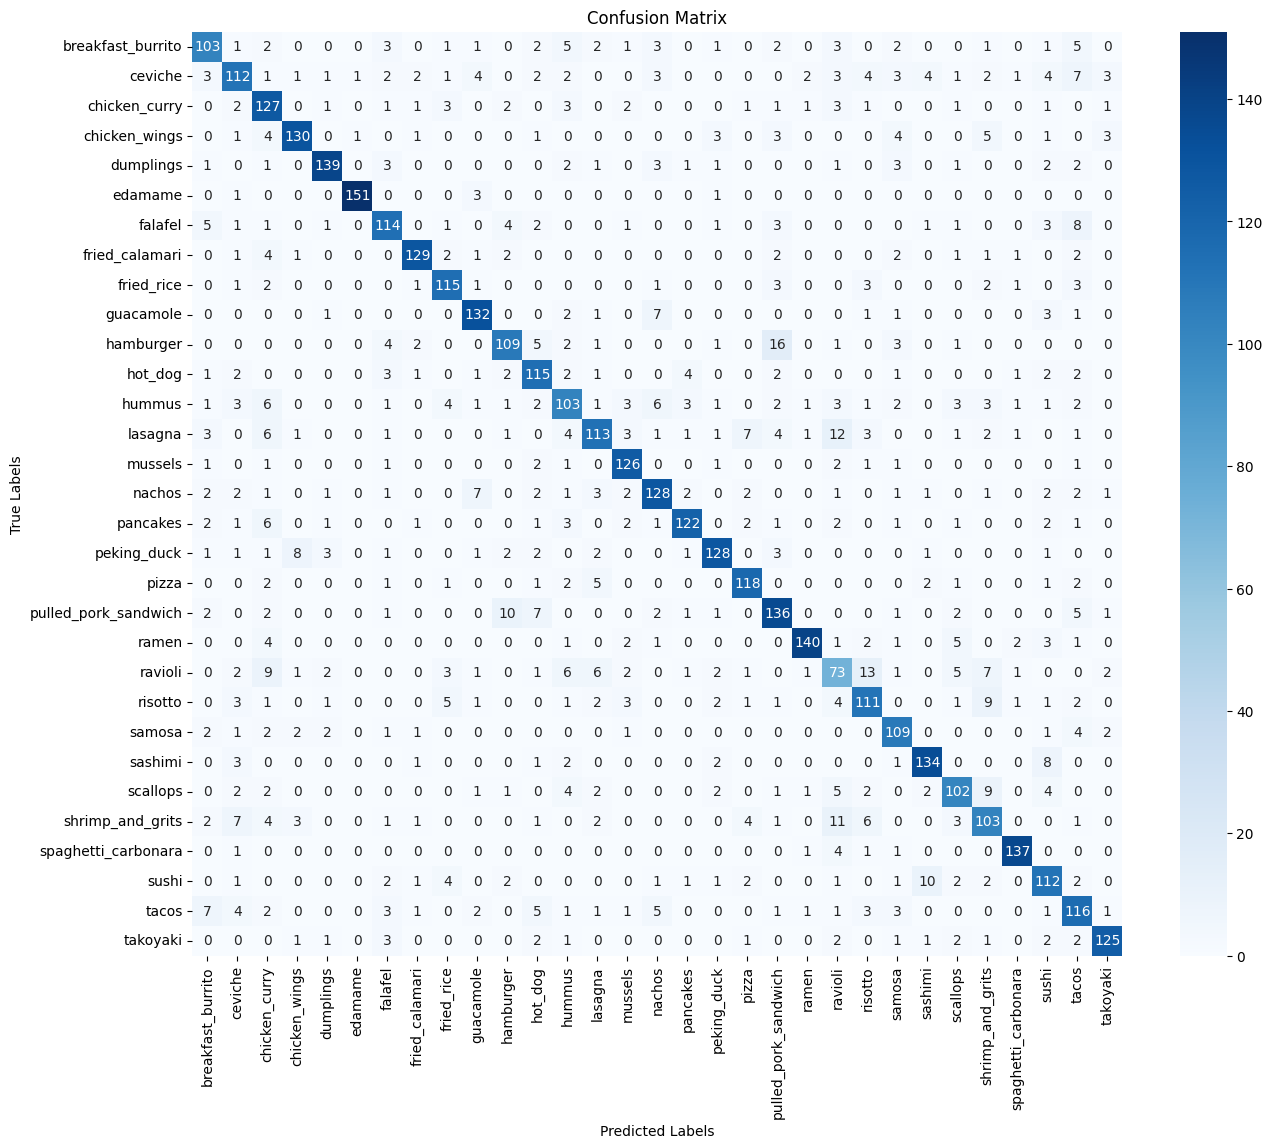

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[reindexed_to_class[i] for i in range(num_classes)], yticklabels=[reindexed_to_class[i] for i in range(num_classes)])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [68]:
import gc
torch.cuda.empty_cache()

In [ ]:
# save all the test images from the data loader
test_images = []
for imgs, _ in test_loader:
    for i in range(imgs.size(0)):
        test_images.append(imgs[i].cpu())

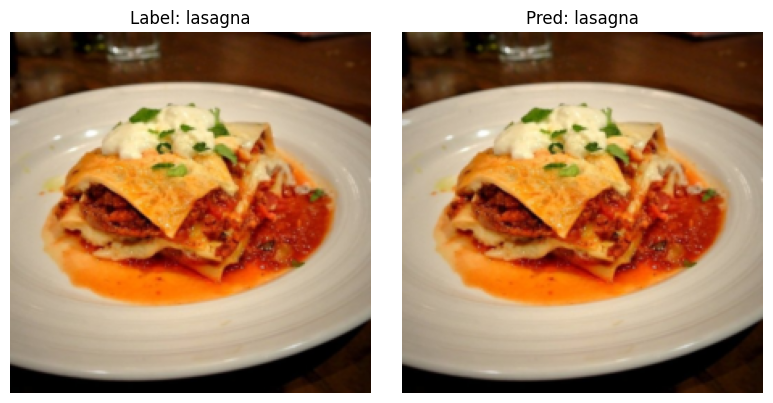

In [82]:
## let's plot some examples of images with ground truth and prediction

# Pick a random index from the whole test set
idx = random.randint(0, len(all_labels) - 1)

# Get label and prediction from the previous evaluation
label_int = all_labels[idx]
pred_int = all_preds[idx]

label_class = reindexed_to_class[label_int]
pred_class = reindexed_to_class[pred_int]
img = test_images[idx]
# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
img_disp = np.clip(img_disp, 0, 1)

# Plot with two subplots: left = true label, right = prediction
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_disp)
axes[0].axis("off")
axes[0].set_title(f"Label: {label_class}")

axes[1].imshow(img_disp)
axes[1].axis("off")
axes[1].set_title(f"Pred: {pred_class}")

plt.tight_layout()
plt.show()


## Application part

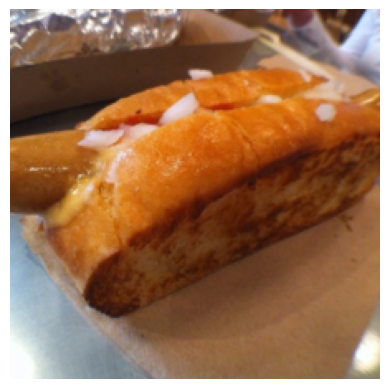

In [85]:
idx = random.randint(0, len(all_labels) - 1)

# Get label and prediction
label_int = all_labels[idx]
label_class = reindexed_to_class[label_int]

img = test_images[idx]
# Inverse normalization
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)
img_disp = inv_normalize(img).permute(1, 2, 0).numpy()
img_disp = np.clip(img_disp, 0, 1)

plt.imshow(np.clip(img_disp, 0, 1))
plt.axis("off")
plt.show()

### "_This dish is delicious!_"
### "_What is its name? Where can I eat it?_"

In [88]:
pred_int = all_preds[idx]
pred_class = reindexed_to_class[pred_int]
cuisine_keys = list(food_subset.keys())
cuisine_index = np.argwhere([pred_class in dishes for dishes in food_subset.values()])[0][0]

print(f"The current dish is *{pred_class}* and its cuisine is *{cuisine_keys[cuisine_index]}*")

The current dish is *hot_dog* and its cuisine is *american*


In [90]:
print(f"Restaurants in {city_name} that offer {cuisine_keys[cuisine_index]} cuisine are:")
gdf_expanded[gdf_expanded["cuisine_main"]==cuisine_keys[cuisine_index]]

Restaurants in Reggio Emilia, Italy that offer american cuisine are:


,name,cuisine,lon,lat,cuisine_main,cuisine_main_all
2,Birreria Red Mosquito,burger,10.667718,44.597387,american,tradizionale; american
16,Osteria dell'Aviatore,grill,10.662529,44.701343,american,tradizionale; american
34,Robe Steakhouse,sandwich,10.696372,44.598153,american,american
103,Roadhouse,steak_house,10.767531,44.654741,american,american
110,Magik Burger,burger,10.772262,44.654114,american,american
131,Trattoria del Macellaio Fornaciari,steak_house,10.659131,44.688438,american,tradizionale; american
148,Terme del Colesterolo,sandwich,10.632295,44.696805,american,american; tradizionale
167,Sedicipiadina,diner,10.452989,44.710715,american,american; tradizionale
172,Bracente,steak_house,10.647269,44.722761,american,tradizionale; american
245,La JoHanna,breakfast,10.742986,44.713990,american,american; pizza


## Curiosities

### Which are the dishes that are confused the most? 


Coppie di classi più spesso confuse (considerando entrambe le direzioni):
hamburger ↔ pulled_pork_sandwich: 26 volte
lasagna ↔ ravioli: 18 volte
ravioli ↔ shrimp_and_grits: 18 volte
sashimi ↔ sushi: 18 volte
ravioli ↔ risotto: 17 volte
risotto ↔ shrimp_and_grits: 15 volte
guacamole ↔ nachos: 14 volte
breakfast_burrito ↔ tacos: 12 volte
chicken_curry ↔ ravioli: 12 volte
lasagna ↔ pizza: 12 volte


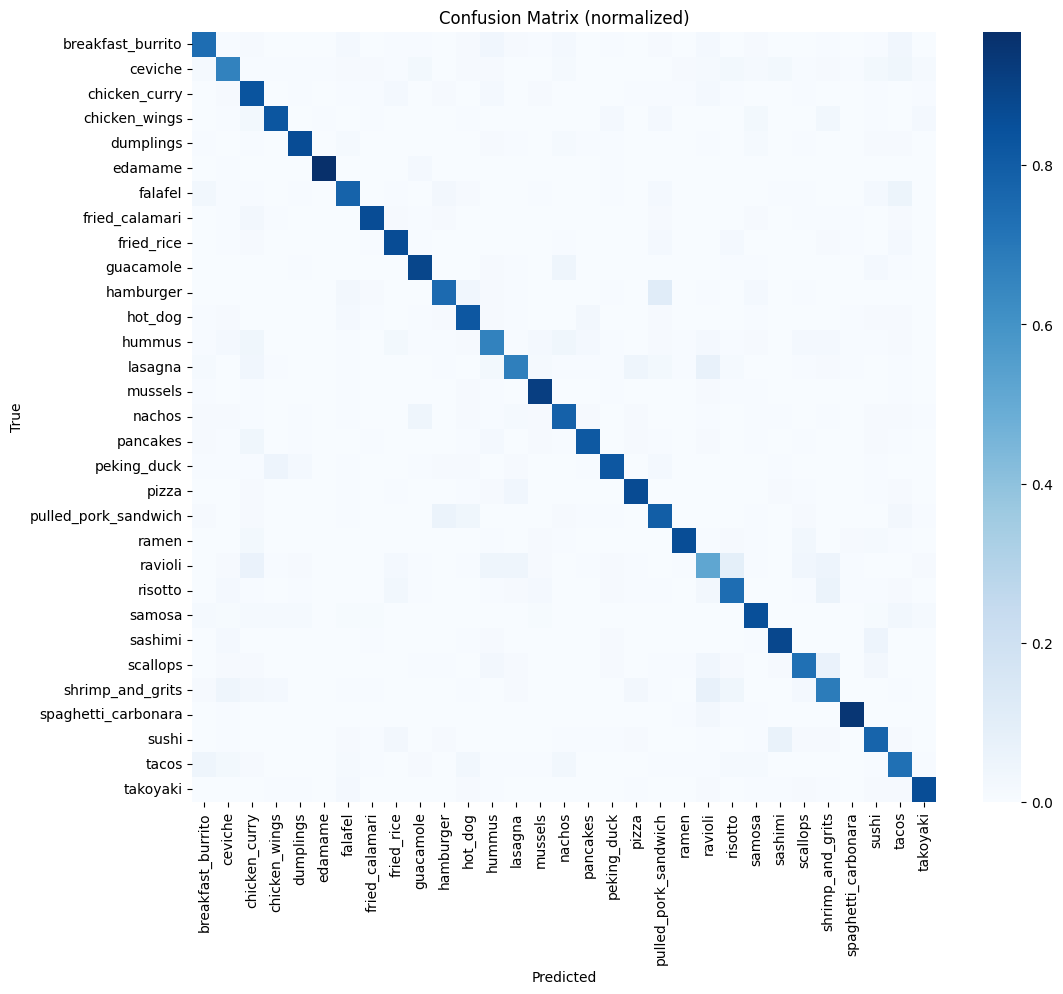

In [98]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

from collections import defaultdict
confusions_combined = defaultdict(int)

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            # Sort the pair so (i,j) and (j,i) are treated as the same confusion
            key = tuple(sorted((reindexed_to_class[i], reindexed_to_class[j])))
            confusions_combined[key] += cm[i, j]
confusions_sorted = sorted(confusions_combined.items(), key=lambda x: x[1], reverse=True)

print("Coppie di classi più spesso confuse (considerando entrambe le direzioni):")
for (class_a, class_b), count in confusions_sorted[:10]:
    print(f"{class_a} ↔ {class_b}: {count} volte")

# # 5. (Opzionale) Heatmap confusion matrix normalizzata
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=False, cmap="Blues", 
            xticklabels=[reindexed_to_class[i] for i in range(len(cm))],
            yticklabels=[reindexed_to_class[i] for i in range(len(cm))])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (normalized)")
plt.show()